<a href="https://www.kaggle.com/code/lalit7881/global-fuel-prices-2020-26-eda?scriptVersionId=309801227" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/belbino/global-fuel-prices-20202026/global_fuel_prices_2020_2026.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/belbino/global-fuel-prices-20202026/global_fuel_prices_2020_2026.csv")

In [3]:
df.head()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
0,2020-01-06,United States,North America,High,Low,1.465,1.289,1.093,65.75,59.6
1,2020-01-13,United States,North America,High,Low,1.435,1.319,1.077,65.54,27.6
2,2020-01-20,United States,North America,High,Low,1.446,1.329,1.080,66.51,62.3
3,2020-01-27,United States,North America,High,Low,1.488,1.359,1.125,68.79,44.8
4,2020-02-03,United States,North America,High,Low,1.457,1.341,1.111,68.44,51.4


In [4]:
df.tail()

,date,country,region,income_level,subsidy_level,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
27463,2026-03-09,Rwanda,Africa,Low,Low,3.036,2.849,2.294,130.0,62.3
27464,2026-03-16,Rwanda,Africa,Low,Low,3.020,2.861,2.248,130.0,43.3
27465,2026-03-23,Rwanda,Africa,Low,Low,3.072,2.825,2.334,130.0,64.1
27466,2026-03-30,Rwanda,Africa,Low,Low,3.045,2.816,2.282,130.0,43.7
27467,2026-04-06,Rwanda,Africa,Low,Low,3.064,2.846,2.296,130.0,63.7


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27468 entries, 0 to 27467
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   date              27468 non-null  object 
 1   country           27468 non-null  object 
 2   region            27468 non-null  object 
 3   income_level      27468 non-null  object 
 4   subsidy_level     27468 non-null  object 
 5   petrol_usd_liter  27468 non-null  float64
 6   diesel_usd_liter  27468 non-null  float64
 7   lpg_usd_liter     27468 non-null  float64
 8   brent_crude_usd   27468 non-null  float64
 9   tax_percentage    27468 non-null  float64
dtypes: float64(5), object(5)
memory usage: 2.1+ MB


In [6]:
df.describe()

,petrol_usd_liter,diesel_usd_liter,lpg_usd_liter,brent_crude_usd,tax_percentage
count,27468.000000,27468.000000,27468.000000,27468.000000,27468.000000
mean,2.281915,2.133760,1.711473,106.686453,26.774468
std,1.540612,1.465058,1.155543,18.972391,17.203349
min,0.010000,0.010000,0.010000,47.970000,0.000000
25%,0.926000,0.858000,0.695000,101.140000,13.500000
50%,2.116500,1.954500,1.588000,112.270000,23.400000
75%,3.457000,3.231000,2.590000,119.410000,38.900000
max,6.779000,6.240000,5.100000,130.000000,65.000000


In [7]:
df.isnull().sum()

date                0
country             0
region              0
income_level        0
subsidy_level       0
petrol_usd_liter    0
diesel_usd_liter    0
lpg_usd_liter       0
brent_crude_usd     0
tax_percentage      0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

date                 object
country              object
region               object
income_level         object
subsidy_level        object
petrol_usd_liter    float64
diesel_usd_liter    float64
lpg_usd_liter       float64
brent_crude_usd     float64
tax_percentage      float64
dtype: object

In [10]:
df.shape

(27468, 10)

In [11]:
df.nunique()

date                 327
country               84
region                 7
income_level           3
subsidy_level          4
petrol_usd_liter    5540
diesel_usd_liter    5257
lpg_usd_liter       4307
brent_crude_usd      303
tax_percentage       651
dtype: int64

In [12]:
df.columns

Index(['date', 'country', 'region', 'income_level', 'subsidy_level',
       'petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter',
       'brent_crude_usd', 'tax_percentage'],
      dtype='object')

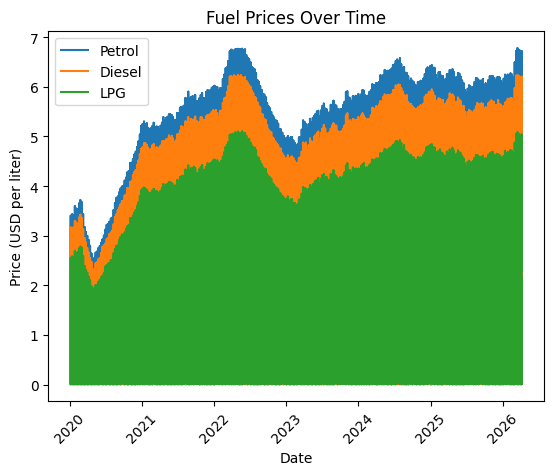

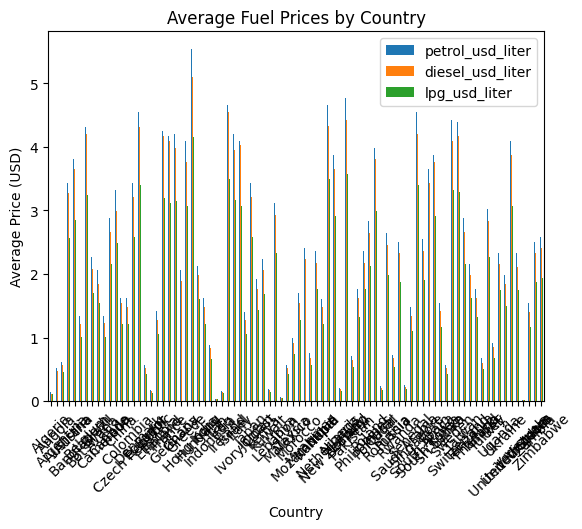

<Figure size 640x480 with 0 Axes>

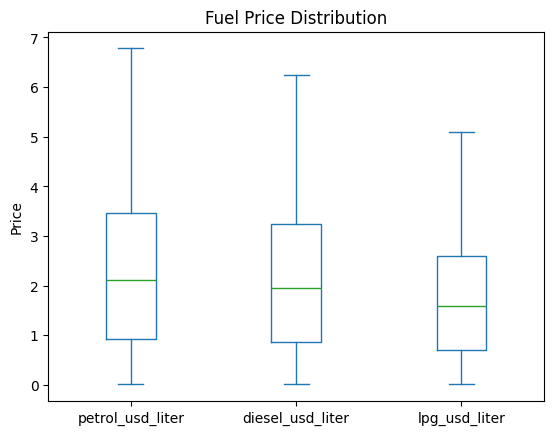

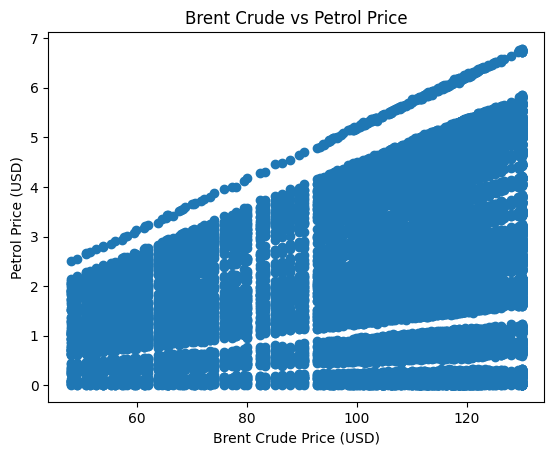

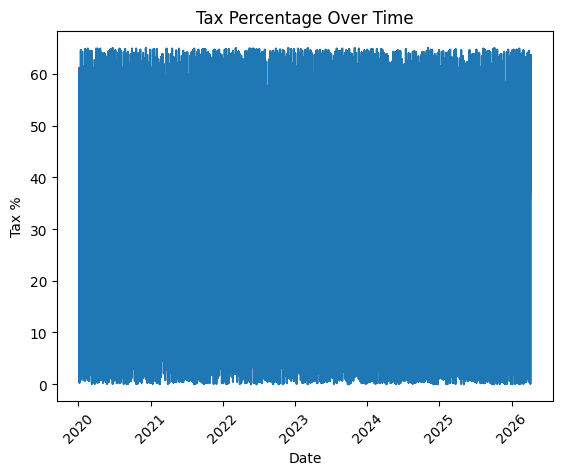

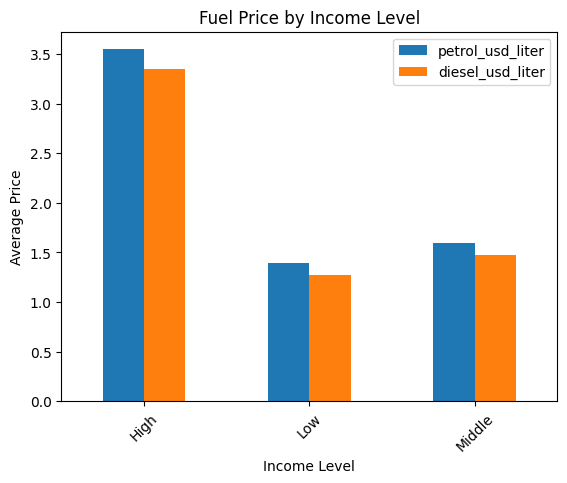

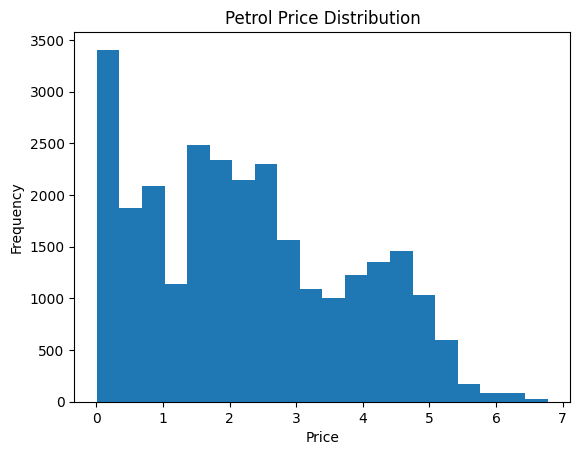

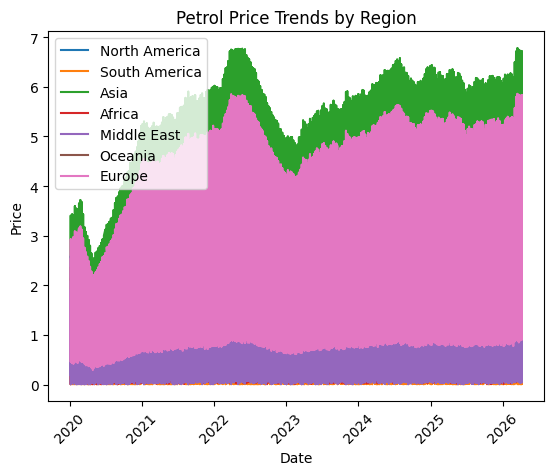

In [13]:
# Convert date column to datetime
df['date'] = pd.to_datetime(df['date'])

# Sort values by date
df = df.sort_values('date')

# -------------------------------
# 1. Line Plot - Fuel Prices Over Time
# -------------------------------
plt.figure()
plt.plot(df['date'], df['petrol_usd_liter'], label='Petrol')
plt.plot(df['date'], df['diesel_usd_liter'], label='Diesel')
plt.plot(df['date'], df['lpg_usd_liter'], label='LPG')

plt.title("Fuel Prices Over Time")
plt.xlabel("Date")
plt.ylabel("Price (USD per liter)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 2. Bar Plot - Average Prices by Country
# -------------------------------
avg_prices = df.groupby('country')[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']].mean()

avg_prices.plot(kind='bar')
plt.title("Average Fuel Prices by Country")
plt.xlabel("Country")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 3. Box Plot - Price Distribution
# -------------------------------
plt.figure()
df[['petrol_usd_liter', 'diesel_usd_liter', 'lpg_usd_liter']].plot(kind='box')

plt.title("Fuel Price Distribution")
plt.ylabel("Price")
plt.show()

# -------------------------------
# 4. Scatter Plot - Crude Oil vs Petrol Price
# -------------------------------
plt.figure()
plt.scatter(df['brent_crude_usd'], df['petrol_usd_liter'])

plt.title("Brent Crude vs Petrol Price")
plt.xlabel("Brent Crude Price (USD)")
plt.ylabel("Petrol Price (USD)")
plt.show()

# -------------------------------
# 5. Line Plot - Tax Percentage Over Time
# -------------------------------
plt.figure()
plt.plot(df['date'], df['tax_percentage'])

plt.title("Tax Percentage Over Time")
plt.xlabel("Date")
plt.ylabel("Tax %")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 6. Grouped Bar Plot - Income Level Comparison
# -------------------------------
income_group = df.groupby('income_level')[['petrol_usd_liter', 'diesel_usd_liter']].mean()

income_group.plot(kind='bar')
plt.title("Fuel Price by Income Level")
plt.xlabel("Income Level")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 7. Histogram - Petrol Price Distribution
# -------------------------------
plt.figure()
plt.hist(df['petrol_usd_liter'], bins=20)

plt.title("Petrol Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

# -------------------------------
# 8. Region-wise Trend (Multiple Lines)
# -------------------------------
regions = df['region'].unique()

plt.figure()
for region in regions:
    temp = df[df['region'] == region]
    plt.plot(temp['date'], temp['petrol_usd_liter'], label=region)

plt.title("Petrol Price Trends by Region")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.xticks(rotation=45)
plt.show()

## Feature engineering


Logistic Regression
Accuracy: 0.995085547870404
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00      2747
           1       1.00      0.99      1.00      2747

    accuracy                           1.00      5494
   macro avg       1.00      1.00      1.00      5494
weighted avg       1.00      1.00      1.00      5494


Random Forest
Accuracy: 0.9972697488168911
Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      2747
           1       1.00      1.00      1.00      2747

    accuracy                           1.00      5494
   macro avg       1.00      1.00      1.00      5494
weighted avg       1.00      1.00      1.00      5494


SVM
Accuracy: 0.9898070622497269
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99      2747
           1       0.99      0.99     

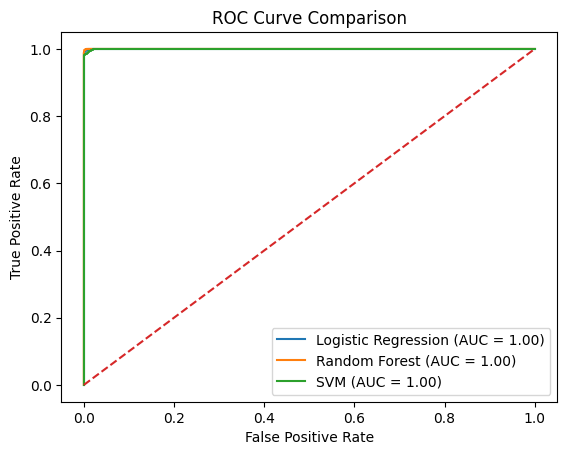

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC



# Convert date
df['date'] = pd.to_datetime(df['date'])

# -------------------------------
# 2. Feature Engineering
# -------------------------------
# Extract useful features from date
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# Drop original date (avoid leakage)
df = df.drop(columns=['date'])

# -------------------------------
# 3. Create Target Variable
# -------------------------------
# Example: classify HIGH vs LOW petrol price
df['target'] = (df['petrol_usd_liter'] > df['petrol_usd_liter'].median()).astype(int)

# Drop leakage column (VERY IMPORTANT)
df = df.drop(columns=['petrol_usd_liter'])

# -------------------------------
# 4. Separate Features & Target
# -------------------------------
X = df.drop(columns=['target'])
y = df['target']

# -------------------------------
# 5. Train-Test Split (BEFORE encoding/scaling)
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 6. Label Encoding (NO DATA LEAKAGE)
# -------------------------------
categorical_cols = ['country', 'region', 'income_level', 'subsidy_level']

encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    
    # Fit ONLY on training data
    X_train[col] = le.fit_transform(X_train[col])
    
    # Apply same mapping on test
    X_test[col] = le.transform(X_test[col])
    
    encoders[col] = le

# -------------------------------
# 7. Feature Scaling (ONLY numeric)
# -------------------------------
scaler = StandardScaler()

numeric_cols = X_train.select_dtypes(include=np.number).columns

X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

# -------------------------------
# 8. Train Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    
    print(f"\n{name}")
    print("Accuracy:", acc)
    print("Classification Report:\n", classification_report(y_test, y_pred))
    
    results[name] = (y_prob, acc)

# -------------------------------
# 9. ROC Curve
# -------------------------------
plt.figure()

for name, (y_prob, acc) in results.items():
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# Diagonal line
plt.plot([0, 1], [0, 1], linestyle='--')

plt.title("ROC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

## Thank you..pls upvote!!!!!!!!!!